# Lab 01: Data wrangling and EDA

**You should add this to a personal Github repo and submit the link to the repo in Canvas.** Add your name to the top of this document and anyone you worked with.

The goal of this lab is to practice working with datasets using Pandas and explore a dataset with plotting and basic statistics. In particular, we will look at a plot to track flows (association between two categoricals): the alluvial diagram.

Here is your lab prompt: You are advising the University of Virginia’s Office of Development on opportunities to expand philanthropic support from international sources. Using the foreign-giving data provided, develop a short strategic plan identifying the countries, institutions, or donor segments UVA should prioritize for future engagement.

Your recommendations should be evidence-based. Use the data to identify patterns in giving, compare potential sources of support, and explain why particular markets or institutions appear especially promising. Support your conclusions with appropriate summaries and visualizations, and translate your findings into a small set of concrete recommendations for the Director of Development.,

1. In your first .ipynb or .py file called **initial_analysis** complete the following steps:
     1. Load the Foreign Gifts data.
     2. Describe the differences between different classes of gift types.
     3. Answer the following questions:
         1. Which country gives the most money in total?
         2. Which country initiates the most gifts by count?
         3. Which country gives the largest gifts on average?
         4. Which institution receive the most money in total?
         5. Which institution receive the greatest number of gifts by count?
         6. What is the average amount each university receives? Median amount? If they are different why?
         7. What is the largest flow of a single country to a single institution?
         8. Which are the top giftors to US academic institutions?
 2. In a new .ipynb/.py file called **uva_analysis**, analyze foreign giving to UVA. Compare UVA to appropriate peer institutions and the market overall. Propose a strategy for finding new sources of foreign money and provide a quantitative analysis.
 3. In a document file (.doc, .docx, .pdf, etc.), summarize your findings:
     1. Executive Summary: What are your main findings and recommendations, in a single paragraph?
     2. Summarize the results of your initial analyses of overall giving and giving to UVA (1-3 paragraphs).
     3. Describe a strategy for finding new potential sources of money for UVA. What countries or institutions should UVA target, and why? (1-3 paragraphs)
     4. Conclude with a summary of UVA's prospects for increasing foreign giving. (1 paragraph).

 In total, your submission repo contain submit at least .ipynb/.py analysis files and a document file with your report (.doc, .docx, .pdf, etc.). If you divide the work among members of a group, make sure that you understand the code being written and submitted by the other members of your group.



## The standard stack: importing packages + reading in the data

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_dummyCoded.csv',low_memory=False)



<font color = "red">
Describe the difference between the gift types:


Contracts are by definition primarily a quid quo pro agreement, and as a result, cannot really be classified as philanthropic donations. Because we do not have access to the contracts, we are unclear as to the obligations of the university and giftor. Most of the larger contracts appear to be branch campuses. 

Legally,it is defined in US Higher Education Act 20 U.S. Code § 1011f - Disclosures of foreign Gifts as "any agreement for the acquisition by purchase, lease, or barter of property or services by the foreign source, for the direct benefit or use of either of the parties."

Contracts are not gifts as demontrated in the legal definition of the term used by the agency in which this list was populated.


 A gift is a voluntary one directional transfer of assets from one party to another, which more resembles a philanthropic donation. 

Real estate gifts are an extremely small category (11 data points) and an insignificant amount of money, which are mostly coming from one country, Japan, to one university, Temple.  They likely refer to branch campus transactions. Their number is too few to really conduct any meaningful analysis.



<font color = "red">

## Added Categorical Columns populated and dummy coded 
<font color = "black">

### by Claude Sonnet High
 Justification for this form of filtering is documented and justified in the "DataFilteringLab1.doc" in the associated repository.  The code generated by claude for this is in a separate ipynb notebook called "AddingCategoricalVariablesToForeignGifts.ipynb".


 
1) Public/Private -  Codes each institution as public and private due to different legistation for receiving and reporting gifts for private and public universities.  For-profit universities are coded as private.

2) Classification of giftor - Codes each gifter as a charity, industry, academic/reesearch, individual or anonymous.

3) Geographic location -  Groups countries into a general geographic region (as defined by SAL HERE)

4) Public ivies classification- expanded and core public ivies- am only using core -comparable groups for uva

*Note: I will be using a filtered data set for parts the global analysis as I find some of the categories in certain variables to be tangential to the purpose of the analysis dictated by the assignment.  Arguments for  for the removal of certain parts of the data set are outlined in my justification document in my repository.

<font color = "red">
Part 1: Exploring what regions have money and what they are giving? Non-filtered but cateegorical variables are added and used.

In [3]:
summary = (df.groupby(["region", "Gift Type"])["Foreign Gift Amount"].agg(count = "count", sum = "sum").reset_index())
summary



,region,Gift Type,count,sum
0,East Asia & Pacific,Contract,4032,2160225888
1,East Asia & Pacific,Monetary Gift,4390,1993729836
2,East Asia & Pacific,Real Estate,8,6892085
3,Europe & Central Asia,Contract,7546,2653880938
4,Europe & Central Asia,Monetary Gift,3740,1905301494
5,Europe & Central Asia,Real Estate,2,3483835
6,Latin America & Caribbean,Contract,596,305822865
7,Latin America & Caribbean,Monetary Gift,459,256682437
8,Latin America & Caribbean,Real Estate,1,4312000
9,Middle East & North Africa,Contract,3011,4223227352


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'East Asia & Pacific'),
  Text(1, 0, 'Europe & Central Asia'),
  Text(2, 0, 'Latin America & Caribbean'),
  Text(3, 0, 'Middle East & North Africa'),
  Text(4, 0, 'North America'),
  Text(5, 0, 'Other / International'),
  Text(6, 0, 'South Asia'),
  Text(7, 0, 'Sub-Saharan Africa')])

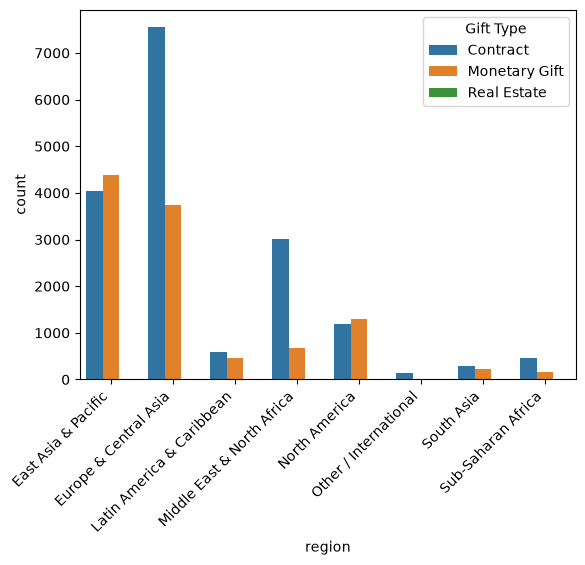

In [4]:
#How many gifts per region per type
sns.barplot( data=summary, x='region', y='count', hue='Gift Type', legend=True)
plt.xticks(rotation=45, ha="right")

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'East Asia & Pacific'),
  Text(1, 0, 'Europe & Central Asia'),
  Text(2, 0, 'Latin America & Caribbean'),
  Text(3, 0, 'Middle East & North Africa'),
  Text(4, 0, 'North America'),
  Text(5, 0, 'Other / International'),
  Text(6, 0, 'South Asia'),
  Text(7, 0, 'Sub-Saharan Africa')])

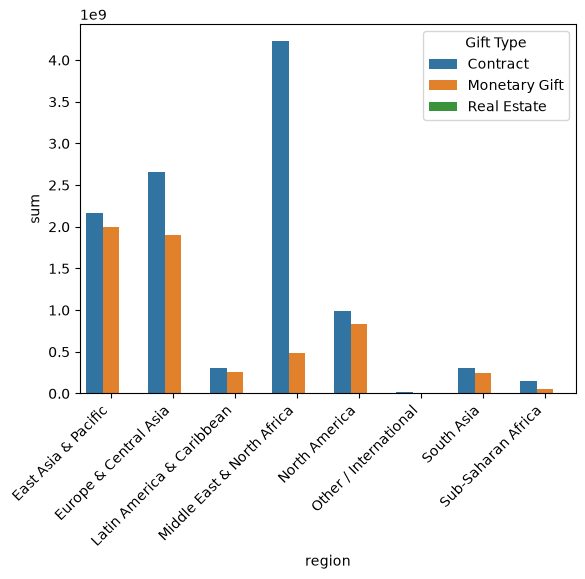

In [5]:
#Total sum of money given by each region per type
sns.barplot( data= summary, x='region', y='sum', hue='Gift Type', legend=True)
plt.xticks(rotation=45, ha="right")

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'East Asia & Pacific'),
  Text(1, 0, 'Europe & Central Asia'),
  Text(2, 0, 'Middle East & North Africa'),
  Text(3, 0, 'North America'),
  Text(4, 0, 'Sub-Saharan Africa'),
  Text(5, 0, 'Latin America & Caribbean'),
  Text(6, 0, 'South Asia'),
  Text(7, 0, 'Other / International')])

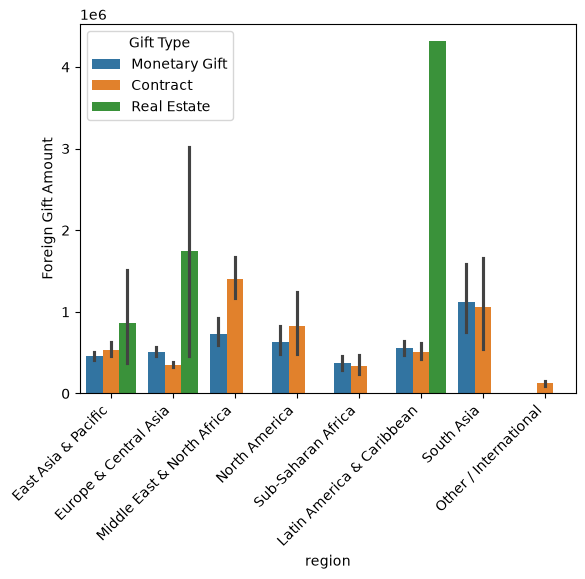

In [6]:
#Averge Gift Amount - I dont really know how important this is to be honest
sns.barplot( data=df, x='region', y='Foreign Gift Amount', hue='Gift Type', legend=True, errorbar = "ci")
plt.xticks(rotation=45, ha="right")

<font color = "red">
EAST ASIA AND EUROPE:
These numbers are telling and in graphs--it is obvious. The two regions, East Asia and Europe, are giving a lot of money in a large number gifts.  They tend to be roughly equivalent in amount in both contracts and gifts. Contracts seem to be given in a higher number --means they are smaller in size. 
These places seem to give money in contracts and gifts equally often, not just contracts, suggesting they would be good areas to look for donations.


North america is smaller than these two but the pattern is similar. Potential for donation opportunities could be there, but more money would likely be received from a similar amount of effort from Europe and East Asia.

MIDDLE EAST:

This area has a ton of money that it is giving -- but this is primarily for contracts.  They are not giving money without getting something back for it contractually.  All of the money coming from here has strings attached. As a result, they do not seem like a good area to target.   



OTHER AREAS: 


They are not really areas that are donating substantial sums money. Most seems from charities.  If they are to be targeted, charities should be the primary focus.

***Aside: I looked into the Quatar-Cornell/Carneige Mellon, because it was A LOT of contract money. This money is for branch campuses. They are not without huge overhead and organizational costs to the university. These are not what UVA is asking for in this analysis in terms of philanthropic donation.  
https://www.forbes.com/sites/bryanpenprase/2026/08/31/beyond-the-middle-east-headlines-building-qatars-education-city/




Addition from later: I noticed some of the North America gifts are coming from the USA -- something is miscoded in this dataset in North American gifts.  I looked deeper into this below, because it was a red flag in the data. See below. 

In [7]:
#checking out the north america group --red flags here

usaGifts = df.loc[df['Country of Giftor'] == 'USA']
norAmerGifts =  df.loc[df['region'] == 'North America']


usaGifts["Foreign Gift Amount"].agg(["count", "sum"])

usaGifts["Foreign Gift Amount"].sum()/norAmerGifts["Foreign Gift Amount"].sum()
#USA gifts are 1%

norAmerGifts.groupby("Country of Giftor")["Foreign Gift Amount"].agg(["sum", "count"])

#BERMUDA?! What!! 
#Ohhhhh
# --see here: https://www.goacta.org/2026/03/67-billion-in-foreign-gifts-pervasive-noncompliance-on-disclosure/
#Money funneling, tax evasion....



,sum,count
Country of Giftor,,
BERMUDA,899593972,117
CANADA,898160656,2344
USA,18704349,36


In [8]:
norAmerGifts.groupby(["Country of Giftor", "giftor_category"])["Foreign Gift Amount"].agg(["sum", "count"])

sum  count
Country of Giftor giftor_category                                
BERMUDA           Academic/Research Institution     468000      2
                  Anonymous                      845252387     43
                  Charitable Organization         46834475     21
                  Individual                       3269374     36
                  Industry/Corporate               3769736     15
CANADA            Academic/Research Institution   22067748    151
                  Anonymous                      440402162    270
                  Charitable Organization         84007425    136
                  Government/International Body    4283362     12
                  Individual                     239574256   1079
                  Industry/Corporate             107825703    696
USA               Academic/Research Institution     700000      2
                  Charitable Organization          1734000      5
                  Government/International Body    1416498      5
                  Individual                       9140435     10
                  Industry/Corporate               5713416     14

<font color = "red">
The USA data points are probably miscoding or from foreign companies or people given within the US? I cannot tell unless I dig into outside info. Bermuda is a tax haven.  Taking these two out essentially halves the donations from North America. USA gifts are pretty evenly spread across individuals and industry. 

In [9]:
# what type of donors in the regions
#lets get rid on contracts here

df.columns

dfGiftsOnly = df.loc[df['Gift Type'] == 'Monetary Gift']

summary_giftOrigin= dfGiftsOnly. groupby(["region", "giftor_category"])["Foreign Gift Amount"].agg(sum = "sum", count = "count")
summary_giftOrigin


sum  count
region                     giftor_category                                 
East Asia & Pacific        Academic/Research Institution    63185061    177
                           Anonymous                      1092418223   1088
                           Charitable Organization         205262414    244
                           Government/International Body    14198910     15
                           Individual                      375279085   2331
                           Industry/Corporate              243386143    535
Europe & Central Asia      Academic/Research Institution    82558129    161
                           Anonymous                       919169498    939
                           Charitable Organization         325588107    474
                           Government/International Body     8133454     11
                           Individual                      362341715   1794
                           Industry/Corporate              207510591    361
Latin America & Caribbean  Academic/Research Institution    17711345     17
                           Anonymous                       109582241    190
                           Charitable Organization          47699439     86
                           Government/International Body     7156315     15
                           Individual                       61948477    122
                           Industry/Corporate               12584620     29
Middle East & North Africa Academic/Research Institution    27870374     29
                           Anonymous                       112769627    174
                           Charitable Organization          72489818    102
                           Government/International Body    98089969    146
                           Individual                      154261250    168
                           Industry/Corporate               21256261     46
North America              Academic/Research Institution     2940490     11
                           Anonymous                       488151083    241
                           Charitable Organization          96982461    118
                           Government/International Body     1587253      2
                           Individual                      223277278    852
                           Industry/Corporate               17154225     80
Other / International      Individual                             10      1
South Asia                 Academic/Research Institution     5970292     11
                           Anonymous                       102146042    114
                           Charitable Organization          38094913     20
                           Government/International Body      423050      1
                           Individual                       79326897     41
                           Industry/Corporate               18461415     31
Sub-Saharan Africa         Academic/Research Institution      674936      2
                           Anonymous                        40162887    126
                           Charitable Organization           1000000      2
                           Government/International Body     7204628      6
                           Individual                        4277046     14
                           Industry/Corporate                5567191      9

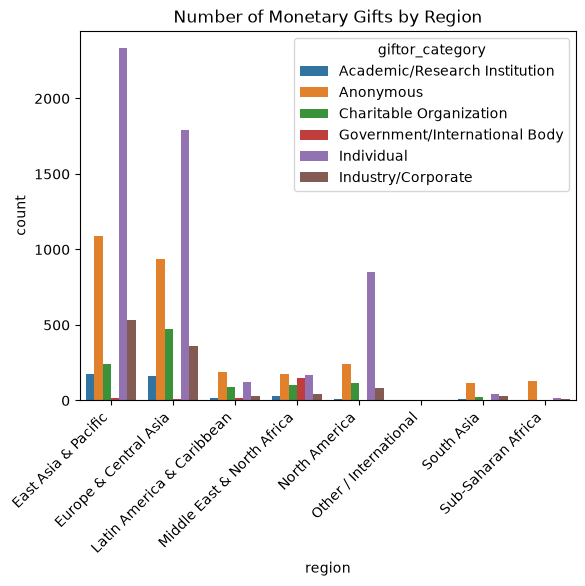

In [10]:

sns.barplot( data=summary_giftOrigin, x='region', y='count', hue='giftor_category', legend=True )
plt.xticks(rotation=45, ha="right")
plt.title("Number of Monetary Gifts by Region")
plt.show()

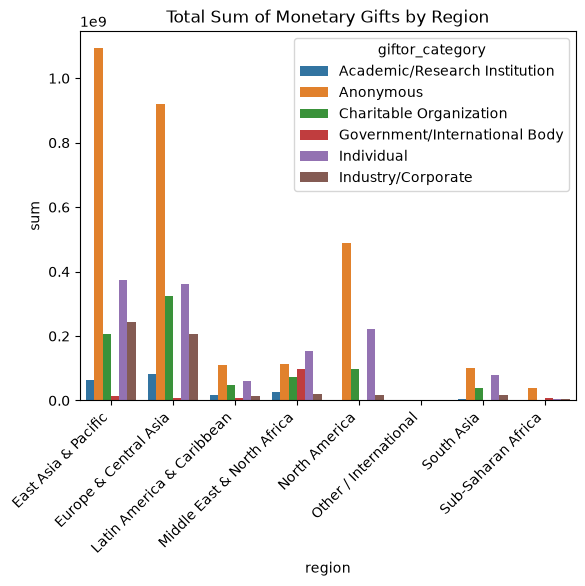

In [11]:

sns.barplot( data=summary_giftOrigin, x='region', y='sum', hue='giftor_category', legend=True)
plt.xticks(rotation=45, ha="right")
plt.title("Total Sum of Monetary Gifts by Region")
plt.show()

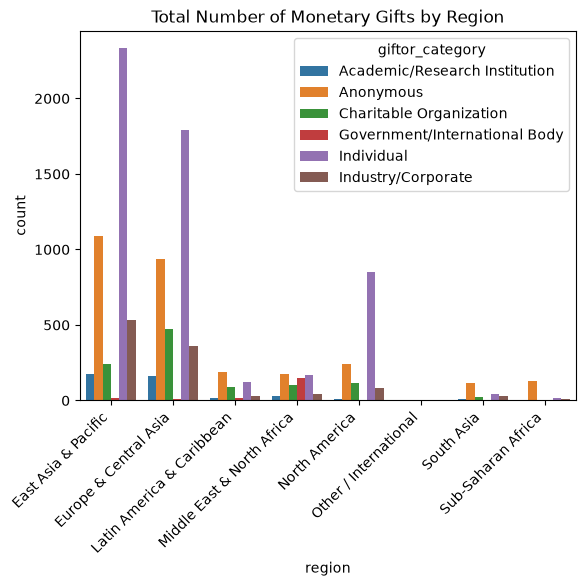

In [12]:
sns.barplot( data=summary_giftOrigin, x='region', y='count', hue='giftor_category', legend=True)
plt.xticks(rotation=45, ha="right")
plt.title("Total Number of Monetary Gifts by Region")
plt.show()

<font color = "red">
Alright, I am willing to bet the farm that if I filter out the private schools, these anonymous bars dissappear.

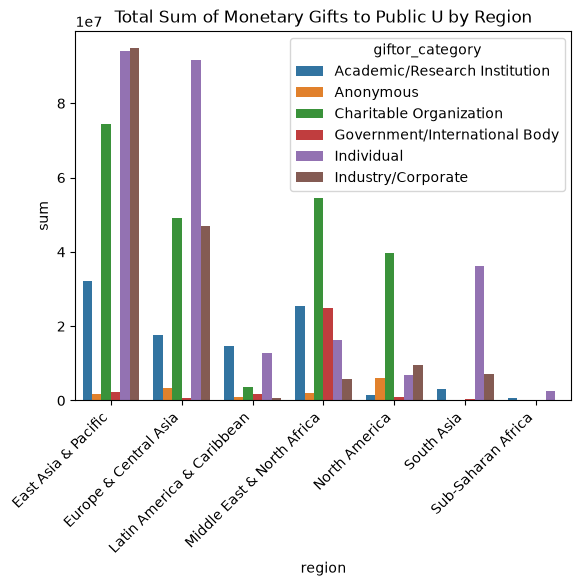

In [13]:
publicGiftsMonetary = dfGiftsOnly.loc[dfGiftsOnly["is_public"] == 1 ]
publicMoneSummary = publicGiftsMonetary.groupby(["region", "giftor_category"])["Foreign Gift Amount"].agg(sum = "sum", count = "count")
sns.barplot( data=publicMoneSummary, x='region', y='sum', hue='giftor_category', legend=True)
plt.xticks(rotation=45, ha="right")
plt.title("Total Sum of Monetary Gifts to Public U by Region")
plt.show()

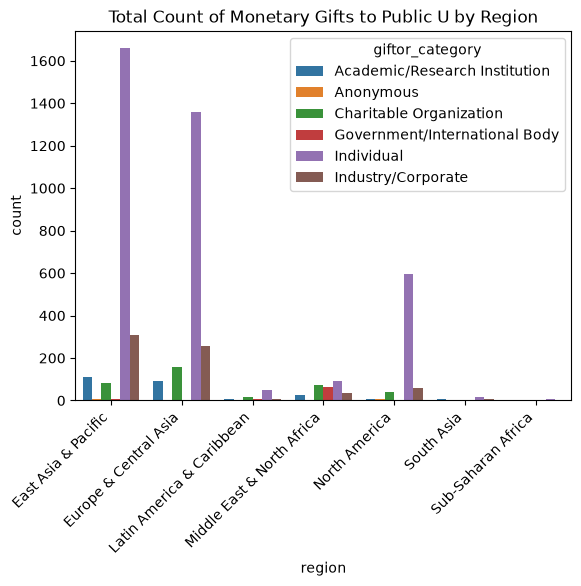

In [14]:
sns.barplot( data=publicMoneSummary, x='region', y='count', hue='giftor_category', legend=True)
plt.xticks(rotation=45, ha="right")
plt.title("Total Count of Monetary Gifts to Public U by Region")
plt.show()

<font color = "red">


Lets look at this.

In [15]:
summaryPblicPr = dfGiftsOnly. groupby(["is_public", "giftor_category"])["Foreign Gift Amount"].agg(sum = "sum", count = "count")
summaryPblicPr

sum  count
is_public giftor_category                                 
0         Academic/Research Institution   105902220    157
          Anonymous                      2850116492   2854
          Charitable Organization         565811141    677
          Government/International Body   105737862    111
          Individual                     1000016159   1543
          Industry/Corporate              361211805    420
1         Academic/Research Institution    95008407    251
          Anonymous                        14283109     18
          Charitable Organization         221306011    369
          Government/International Body    31055717     85
          Individual                      260695599   3780
          Industry/Corporate              164708641    671

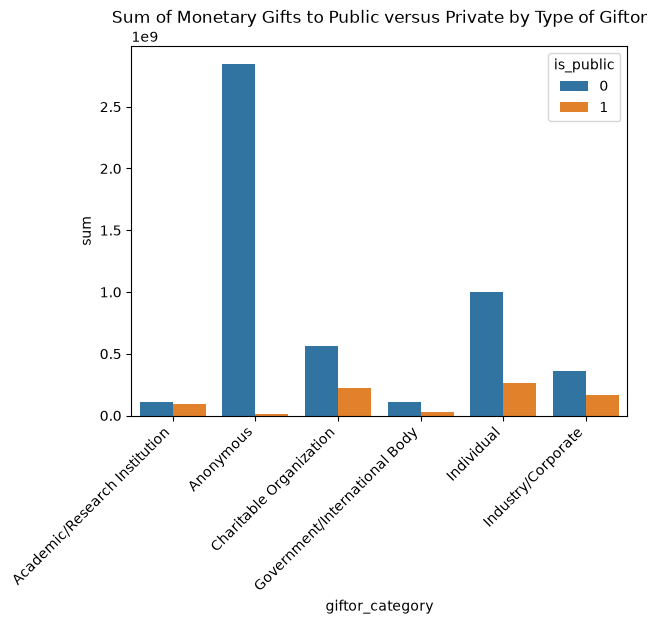

In [16]:
sns.barplot( data=summaryPblicPr, x='giftor_category', y='sum', hue='is_public', legend=True)
plt.xticks(rotation=45, ha="right")
plt.title("Sum of Monetary Gifts to Public versus Private by Type of Giftor")
plt.show()

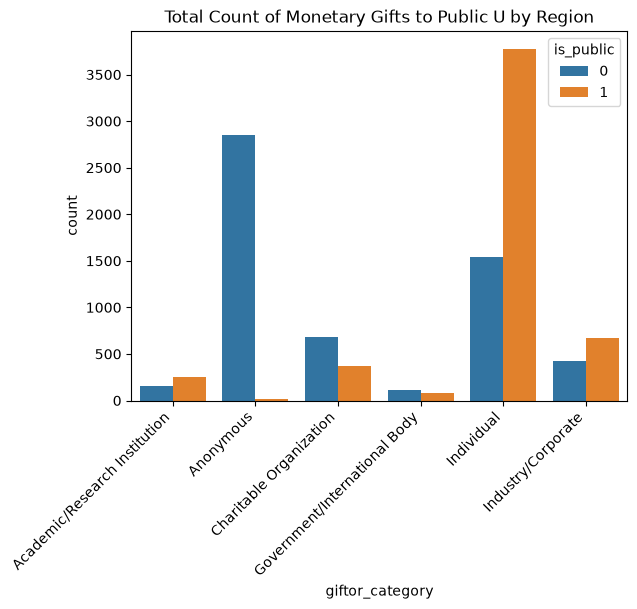

In [17]:
sns.barplot( data=summaryPblicPr, x='giftor_category', y='count', hue='is_public', legend=True)
plt.xticks(rotation=45, ha="right")
plt.title("Total Count of Monetary Gifts to Public U by Region")
plt.show()

<font color = "red">

Okay, so this justifies my filter. 

Private schools do not have to declare the source of their donations. Under almost all state laws, public schools do.  As the success of any university is highly contingent on its reputation, I will speculate that UVA and other public institutions do not take money that they could have because they have to declare the source. This seems to be very apparent in the data. I also don't know why private universities do not declare certain sources (i.e., anonymous), and whether they would have taken the money if they had to report it.  As a result, even their non-anonymous numbers could be skewed by merely not having to disclose -just being lumped in with anonymous. 

**Even outside of the anonymous group, donations could be given to/taken from private schools that would not be considered for public schools, because the private schools may not have declare all of the details of the transaction--even if they declare the source. Put simply, the anonymous source could just be one of the elements in which disclosure influences donations.

Consequently, public schools cannot be compared to private schools in this analysis.  


IMPORTANT: If you look at the first sum graph.  You cannot really attribute to all of the anonymous donations as just coming from individuals -- they already beat public schools in individual donations that are not anonymous.  If it was just individuals-why are some anonymously donating and others not? Also, private unis also are doing better in all areas that are declared. So it is not just that private universities do not declare at all. One could say that some deficit in other funding areas can be explained by the anonymous donations, and intuitively this has to be the case.



In [18]:
df.columns

Index(['Unnamed: 0', 'ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name', 'is_public', 'giftor_category',
       'region', 'public_ivy_core', 'public_ivy_expanded'],
      dtype='object')


<font color = "red">

##  Filter for remainder of analysis

From here I will be using a data set with contracts and private universities filtered out.  I do not think these data contribute anything to the inquiry in terms of UVA soliciting donations and as a result are a distraction.

In [19]:
df_filtered =  dfGiftsOnly.loc[dfGiftsOnly["is_public"] == 1]

df_filtered.head(3).T

,0,7,12
Unnamed: 0,0,7,12
ID,1,8,13
OPEID,102000,105100,105100
Institution Name,Jacksonville State University,University of Alabama,University of Alabama
City,Jacksonville,Tuscaloosa,Tuscaloosa
State,AL,AL,AL
Foreign Gift Received Date,43738,43517,43543
Foreign Gift Amount,250000,200,200
Gift Type,Monetary Gift,Monetary Gift,Monetary Gift
Country of Giftor,CHINA,GERMANY,GERMANY


## Groupby

As we learned, `.groupby` is a super useful way to aggregate the data and explore summary statistics. We can assign the output to a new dataframe, just taking the n largest amounts. Resetting the index just changes the index to integers starting at 0. 

<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?

***England gives the most money, followed closely by East Asian countries. If you look at region, South East Asia and Europe are dominating.  Europe mostly dominated by English and Spanish donations.

</div>


In [ ]:


countrySum =df_filtered.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)
countryPer = (countrySum / countrySum.sum() * 100).round(2)
countrySum
countryPer

Country of Giftor
ENGLAND               9.96
JAPAN                 9.75
HONG KONG             7.62
QATAR                 7.55
CHINA                 6.41
                      ... 
BOLIVIA               0.00
DOMINICAN REPUBLIC    0.00
ECUADOR               0.00
NORTHERN IRELAND      0.00
ERITREA               0.00
Name: Foreign Gift Amount, Length: 78, dtype: float64

In [47]:
df_england_summary  = df_filtered[df_filtered["Country of Giftor"] == "ENGLAND"].groupby("giftor_category")["Foreign Gift Amount"].agg(count = "count", sum = "sum")

dfEngPer = (df_england_summary / df_england_summary.count() * 100).round(2)

countryPer

dfEngPer
#df_england_summary  = df_filtered[(df_filtered["Country of Giftor"] == "ENGLAND") & (df_filtered["Institution Name"] == "University of Virginia")].groupby("giftor_category")["Foreign Gift Amount"].agg(count = "count", sum = "sum")


,count,sum
giftor_category,,
Academic/Research Institution,1280.0,173243300.0
Anonymous,20.0,60000000.0
Charitable Organization,2100.0,595012140.0
Individual,17460.0,356401260.0
Industry/Corporate,1940.0,382898420.0


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Academic/Research Institution'),
  Text(1, 0, 'Anonymous'),
  Text(2, 0, 'Charitable Organization'),
  Text(3, 0, 'Individual'),
  Text(4, 0, 'Industry/Corporate')])

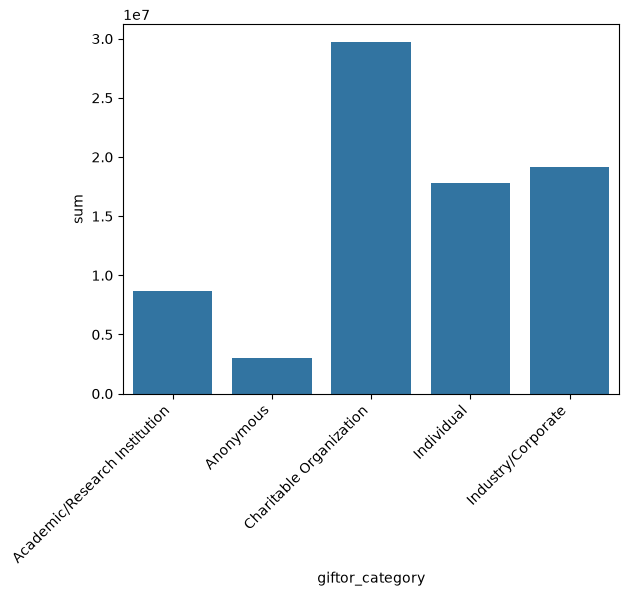

In [22]:
sns.barplot( data= df_england_summary, x='giftor_category', y="sum", legend=True)
plt.xticks(rotation=45, ha="right")

In [23]:
df_filtered.groupby("region")["Foreign Gift Amount"].sum().sort_values(ascending=False)

region
East Asia & Pacific           299724398
Europe & Central Asia         209189547
Middle East & North Africa    128728665
North America                  64715906
South Asia                     46947639
Latin America & Caribbean      34491342
Sub-Saharan Africa              3259987
Name: Foreign Gift Amount, dtype: int64

<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?


**England followed by Canada, and then East Asian countries.  If we look at region, East Asia has a slight edge over Europe, but no other region comes close.
</div>


In [24]:
df_filtered.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False)

Country of Giftor
ENGLAND             1140
CANADA               696
CHINA                641
JAPAN                550
HONG KONG            361
                    ... 
NORTHERN IRELAND       1
PUERTO RICO            1
SERBIA                 1
UKRAINE                1
WALES                  1
Name: Foreign Gift Amount, Length: 78, dtype: int64

In [25]:
df_filtered.groupby("region")["Foreign Gift Amount"].count().sort_values(ascending=False)

region
East Asia & Pacific           2170
Europe & Central Asia         1868
North America                  707
Middle East & North Africa     292
Latin America & Caribbean       92
South Asia                      34
Sub-Saharan Africa              11
Name: Foreign Gift Amount, dtype: int64

<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?


Peru and Burma, but likely because they gave only one or two large gifts. If we look by region, South Asia dominates.  I think countries that donate less overall tend to give only a couple gifts that are larger--perhaps a one time type of thing. 
</div>

In [26]:
df_filtered.groupby("Country of Giftor")["Foreign Gift Amount"].mean().sort_values(ascending=False)

Country of Giftor
PERU                  2.502130e+06
BURMA                 1.843176e+06
INDIA                 1.766646e+06
BERMUDA               1.498750e+06
OMAN                  1.110055e+06
                          ...     
DOMINICAN REPUBLIC    5.000000e+01
ECUADOR               2.100000e+01
NORTHERN IRELAND      1.500000e+01
EGYPT                 1.416667e+01
ERITREA               3.000000e+00
Name: Foreign Gift Amount, Length: 78, dtype: float64

In [27]:
df_filtered.groupby("region")["Foreign Gift Amount"].mean().sort_values(ascending=False)

region
South Asia                    1.380813e+06
Middle East & North Africa    4.408516e+05
Latin America & Caribbean     3.749059e+05
Sub-Saharan Africa            2.963625e+05
East Asia & Pacific           1.381218e+05
Europe & Central Asia         1.119858e+05
North America                 9.153593e+04
Name: Foreign Gift Amount, dtype: float64

## Ordering by institution

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?

UC-Berkley receives the most, followed by UCLA. 

</div>



<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?

UCLA gets the greatest number, followed by Louisville and then UC-Berkeley. California public schools are doing well.
</div>



Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

In [ ]:
df_filtered.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)



Institution Name
University of California, Berkeley                 124905001
University of California, Los Angeles               83400261
Purdue University                                   75504368
Texas A&M University                                54879197
University of California, San Diego                 48890613
                                                     ...    
University of Oklahoma                                 56000
University of Colorado Colorado Springs                33296
Rutgers, the State University of New Jersey            21830
Western Michigan University                             8065
California State Polytechnic University, Pomona         1273
Name: Foreign Gift Amount, Length: 77, dtype: int64

In [29]:
df_filtered.groupby("Institution Name")["Foreign Gift Amount"].count().sort_values(ascending=False)


Institution Name
University of California, Los Angeles    3252
University of Louisville                  190
University of California, Berkeley        189
University of Colorado Boulder            168
Colorado State University                 130
                                         ... 
University of Massachusetts - Amherst       1
University of Florida                       1
University of Tennessee                     1
University of Wyoming                       1
West Virginia University                    1
Name: Foreign Gift Amount, Length: 77, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'University of California, Berkeley'),
  Text(1, 0, 'University of California, Los Angeles'),
  Text(2, 0, 'Purdue University'),
  Text(3, 0, 'Texas A&M University'),
  Text(4, 0, 'University of California, San Diego'),
  Text(5, 0, 'Indiana University - Bloomington'),
  Text(6, 0, 'University of Michigan - Ann Arbor'),
  Text(7, 0, 'University of Texas MD Anderson Cancer Center'),
  Text(8, 0, 'University of Illinois at Urbana-Champaign'),
  Text(9, 0, 'University of California, Davis'),
  Text(10, 0, 'Oregon State University'),
  Text(11, 0, 'Arizona State University'),
  Text(12, 0, 'Georgia Institute of Technology'),
  Text(13, 0, 'University of California, Santa Barbara'),
  Text(14, 0, 'Ohio State University (The)'),
  Text(15, 0, 'University of Texas at Austin'),
  Text(16, 0, 'University of Kansas'),
  Text(17, 0, 'University of Colorado Boulder'),
  Text(18, 0, 'University of California, Irvi

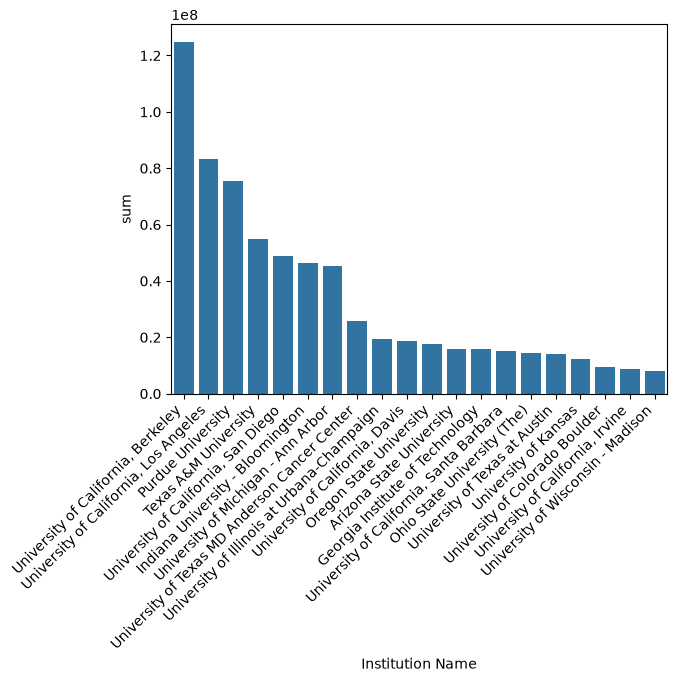

In [30]:
summary_inst = df_filtered.groupby("Institution Name")["Foreign Gift Amount"].agg(count = "count", sum = "sum"). sort_values("sum", ascending=False)
summary_inst
sns.barplot( data= summary_inst.head(20), x='Institution Name', y="sum", legend=True)
plt.xticks(rotation=45, ha="right")

## Comparing summary statistics

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


In [31]:
df_filtered.groupby("Institution Name")["Foreign Gift Amount"].agg(["mean", "median"]).sort_values("mean", ascending=False)


,mean,median
Institution Name,,
Indiana University - Bloomington,2.017887e+06,458627.0
University of Texas Health Science Center at Houston,2.000000e+06,1666667.0
Arizona State University,1.984685e+06,299975.0
Oregon State University,1.365027e+06,565461.0
Lamar University,1.154116e+06,1154116.0
...,...,...
"Rutgers, the State University of New Jersey",1.091500e+04,10915.0
University of Louisville,1.077702e+04,100.0
University of Colorado Colorado Springs,6.659200e+03,1200.0


<font color = "red">


The means tend to be drastically higher than the medians in most Universities foreign gift amounts.  The reason for this difference is likely that a few very large gifts given that differ drastically from most smaller gifts influence the mean more than the median.  



The mean is more influenced by the large gifts than the median as the value of the larger gifts are used in the computation of the mean which allows it pull the mean closer towards its value. Conversely, the value of the medium is determined by its middle position of the data points that are listed in numerical order.  A much larger value  at the top (or bottom) of the numberical order does not affect the position of the middle number.  As a result, the median remains unaffects. 

In [32]:
universitySum = df_filtered.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending = True)

uniHist = px.histogram(universitySum, x = "Foreign Gift Amount")
mean_val = universitySum.mean()
median_val = universitySum.median()


uniHist.add_vline(x=mean_val, line_color="orange", annotation_text="Mean")
uniHist.add_vline(x=median_val, line_color="blue", annotation_text="Median")

uniHist.show()




## Relationship between variables: 
<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?

Quatar to Texas A&M
</div>



### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [33]:
df_filtered.columns
pd.crosstab(df_filtered["Country of Giftor"], df_filtered["Institution Name"])

Institution Name,Arizona State University,"California State Polytechnic University, Pomona","California State University, Bakersfield","California State University, Los Angeles","California State University, San Bernardino","California State University, San Marcos",Clemson University,College of William & Mary,Colorado State University,Georgia Institute of Technology,...,University of Texas at Dallas,University of Texas at San Antonio,University of Toledo,University of Utah,University of Virginia,University of Washington - Seattle,University of Wisconsin - Madison,University of Wyoming,West Virginia University,Western Michigan University
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AUSTRALIA,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AUSTRIA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BAHAMAS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BANGLADESH,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UKRAINE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
UNITED ARAB EMIRATES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
USA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Flow of information using alluvial plots

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in plotly that we'll use.

In [34]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df_filtered.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)



fig.show()




Very cool!

In [35]:


# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df_filtered.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)



fig.show()



In [36]:


# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'region'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df_filtered.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)



fig.show()



In [37]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'giftor_category'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df_filtered.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)



fig.show()



<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?





I just want to reiterate that these conclusions are drawn from data from public universities and monetary gifts only. I have previously justified making these decisions.


It depends on what you mean by this question --whose doing the gifting and what "gifts" are they giving. If you mean by single organizations, then Quatar Foundation gave the most.  By countries, Quatar, Hong Kong, Japan, and England give the most.  By region, East asia and Europe give the most. If you mean by category, it looks like charities and individuals are giving the most.

 The chart of the different countries' contributions seems to be quite illuminating.  Quatar's gift pattern is one massive gift to one Texas A and M.  A quick google search shows that Texas A and M has a branch campus in Quatar, so is this really a charitable gift or a long term investment plan? It is also not really a gift--branch campuses require a great deal of work/money from both the country and the institution. Japan, Spain and India show the same pattern--likely for similar reasons.  These are long term plans and investments from one country to one university -- these sources are not likely to translate into donations to other universities. They have already chosen their investment. This pattern is important, because unless UVA wants to start opening branch campuses, they are unlikely to get money from these countries.
 
   Hong Kong and England both show a pattern of diversity in their giving across several different US universities. These two countries give a lot of money, but ALSO seem to not have a single massive strategic long term goal in one university. I would say these two are the top "gifters", and probably good places to target for donation opportunities.
</div>


In [38]:
df_filtered.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Giftor Name
Qatar Foundation                       50485963
Tata Education and Development Trus    35000000
LA CAIXA DE PENSIONS                   32017614
THE JAPAN FOUNDATION TADASHI YANAI     25000000
Jynwel Charitable Foundation Ltd       15000000
                                         ...   
Park, Kwanhong                                1
SALUS, PETER                                  1
Hatakeyama, Kazumi                            1
COX, MELATI                                   1
McKean, Ross                                  1
Name: Foreign Gift Amount, Length: 3350, dtype: int64

In [39]:
df_filtered.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Country of Giftor
ENGLAND               78377756
JAPAN                 76718883
HONG KONG             59973605
QATAR                 59443118
CHINA                 50436590
                        ...   
BOLIVIA                     50
DOMINICAN REPUBLIC          50
ECUADOR                     21
NORTHERN IRELAND            15
ERITREA                      3
Name: Foreign Gift Amount, Length: 78, dtype: int64

In [40]:
df_filtered.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Country of Giftor
ENGLAND               78377756
JAPAN                 76718883
HONG KONG             59973605
QATAR                 59443118
CHINA                 50436590
                        ...   
BOLIVIA                     50
DOMINICAN REPUBLIC          50
ECUADOR                     21
NORTHERN IRELAND            15
ERITREA                      3
Name: Foreign Gift Amount, Length: 78, dtype: int64